## Welcome to this Jupyter notebook on "Unraveling Academic Dynamics: Co-authorship Networks and Dominant Themes in Bibliometric Data."




In the rapidly evolving landscape of academic research, bibliometric data serves as a treasure trove of insights. By analyzing the relationships between various metadata components like authors, titles, and citations, we can unveil patterns, trends, and dominant themes that shape the contours of scientific thought.

Leveraging the expansive bibliometric dataset from Web of Science, this notebook harnesses the power of the Metaknowledge package to delve deep into the intricacies of co-authorship networks and to discern the dominant academic topics through LDA topic modelling. Our analysis is guided by three primary questions:

Who among the top authors frequently collaborate, making them dominant co-authors?
How does the co-authorship network manifest, and what can we deduce from its structure?
Which themes or topics resonate most in the academic papers under our lens?
As we navigate through the sections of this notebook, we'll employ a systematic approach, starting with data preprocessing, followed by network construction and visualization, and culminating in topic modelling. Along the way, visualizations will enrich our understanding and help crystallize the insights drawn from the data.

Whether you're a bibliometrics enthusiast, a data scientist, or just someone curious about the dynamics of academic research, this notebook aims to provide a comprehensive exploration, replete with insights and visual narratives. So, let's embark on this analytical journey!





In [1]:
!pip install pyLDAvis


In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns



import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
import spacy
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import ldamodel
from gensim.models import CoherenceModel 
import re
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt


from pprint import pprint
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
#!pip install metaknowledge 

In [4]:
#!pip3 install metaknowledge


In [5]:
#!pip3 install python-louvain


In [6]:
import networkx as nx
import metaknowledge as mk
import community


In [7]:
# Importing the information science and bibliometrics dataset
coll_rec = mk.RecordCollection("C:/Users/User/Documents/Project Drills/Bibliometric Analysis/raw_data/imetrics")



In [8]:
len(coll_rec)

8140

In [9]:
coll_rec

<metaknowledge.RecordCollection object files-from-C:\Users\User\Documents\Project Drills\Bibliometric Analysis\raw_data\imetrics>

The data we have is stored in a RecordCollection object. To visualize its contents, it's essential to convert it into a dataframe. 
This conversion can be accomplished through two different methods:
1. Utilizing the Pandas library, or
2. Employing the makeDict() function provided by the Metaknowledge package.


In [10]:
# Saving the dataset as a csv file
coll_rec.writeCSV("biblio_records.csv")
# Reading in the data as a Pandas dataframe
df = pd.read_csv("biblio_records.csv")
df.head(10)

,id,TI,AF,CR,ID,DI,PT,AU,SO,LA,...,SP,EI,HO,SI,CA,PM,num-Authors,num-Male,num-Female,num-Unknown
0,WOS:000322870300006,An Open-Set Size-Adjusted Bayesian Classifier ...,"Schaalje, G. Bruce|Blades, Natalie J.|Funai, T...","Rokach L, 2010, ARTIF INTELL REV, V33, P1, DOI...",LOGISTIC-REGRESSION|SHRUNKEN CENTROIDS,10.1002/asi.22877,J,"Schaalje, GB|Blades, NJ|Funai, T",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,3,0,1,2
1,WOS:000288142600005,P-Rank: An Indicator Measuring Prestige in Het...,"Yan, Erjia|Ding, Ying|Sugimoto, Cassidy R.","Ding Y, 2009, J AM SOC INF SCI TEC, V60, P2229...",JOURNAL SELF-CITATION|PAGERANK ALGORITHM|SCIEN...,10.1002/asi.21461,J,"Yan, E|Ding, Y|Sugimoto, CR",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,3,0,1,2
2,WOS:000273155100004,The Development and Evaluation of a Survey to ...,"O'Brien, Heather L.|Toms, Elaine G.","Aboulafia A., 2004, THEORETICAL ISSUES E, V5, ...",WEB DESIGNERS|ONLINE|FLOW|MOTIVATIONS|TECHNOLO...,10.1002/asi.21229,J,"O'Brien, HL|Toms, EG",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,2,0
3,WOS:000228452400002,A simulation study of the periodicals' publica...,"Yu, G|Yu, DR|Li, YJ","Garfield E, 1999, CAN MED ASSOC J, V161, P979|...",NaN,10.1007/s11192-005-0202-6,J,"Yu, G|Yu, DR|Li, YJ",SCIENTOMETRICS,English,...,NaN,NaN,NaN,NaN,NaN,NaN,3,0,0,3
4,WOS:000227150500006,Integrated bioinformatics application for auto...,"Toldo, L|Rippmann, F","AHONEN H, 1998, LECT NOTES COMPUTER, V1375, P4...",DOCUMENT-RETRIEVAL|GENOME ANNOTATION|SEQUENCE|...,10.1002/asi.20137,J,"Toldo, L|Rippmann, F",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0,2
5,WOS:A1995QH22700002,SOME ASPECTS OF THE EVALUATION OF SCIENTIFIC A...,"VINKLER, P","NICOLINI C, 1995, SCIENTOMETRICS, V32, P93, DO...",INDICATORS,10.1007/BF02016887,J,"VINKLER, P",SCIENTOMETRICS,English,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,1
6,WOS:000238005200015,A semantic web primer.,"Che, Haoyang","Antoniou G, 2004, SEMANTIC WEB PRIMER",NaN,10.1002/asi.20368,J,"Che, HY",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,1
7,WOS:000231158100003,Antitrust environment and innovation,"Marinova, D|McAleer, M|Slottje, D","Baumol WJ, 2001, INT J IND ORGAN, V19, P727, D...",US|VOLATILITY|PATENTS,10.1007/s11192-005-0252-9,J,"Marinova, D|McAleer, M|Slottje, D",SCIENTOMETRICS,English,...,NaN,NaN,NaN,NaN,NaN,NaN,3,0,0,3
8,WOS:A1997WP65300006,The evaluation of European programmes and the ...,"Cunningham, P","NARIN F, 1991, SCIENTOMETRICS, V21, P313, DOI ...",NaN,10.1007/BF02461124,J,"Cunningham, P",SCIENTOMETRICS,English,...,Ministry Educ|Cult Sci Neth|Eur Comm|DG XII|Ro...,NaN,NaN,NaN,NaN,NaN,1,0,0,1
9,WOS:000266303800020,Measuring the Likelihood Property of Scoring F...,"Bache, Richard|Baillie, Mark|Crestani, Fabio","Crestani F, 1998, ACM COMPUT SURV, V30, P528, ...",INFORMATION-RETRIEVAL,10.1002/asi.21048,J,"Bache, R|Baillie, M|Crestani, F",JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,...,NaN,NaN,NaN,NaN,NaN,NaN,3,3,0,0


In [11]:
# Saving the data as a dataframe using mk's makeDict()
df2 = pd.DataFrame(coll_rec.makeDict())
df2.head(10)

,PT,AU,AF,TI,SO,LA,DT,DE,ID,AB,...,SP,EI,HO,SI,CA,PM,num-Authors,num-Male,num-Female,num-Unknown
0,J,"[Schaalje, GB, Blades, NJ, Funai, T]","[Schaalje, G. Bruce, Blades, Natalie J., Funai...",An Open-Set Size-Adjusted Bayesian Classifier ...,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Article,"[automatic classification, text mining, statis...","[LOGISTIC-REGRESSION, SHRUNKEN CENTROIDS]",Recent studies of authorship attribution have ...,...,None,None,None,None,None,None,3,0,1,2
1,J,"[Yan, E, Ding, Y, Sugimoto, CR]","[Yan, Erjia, Ding, Ying, Sugimoto, Cassidy R.]",P-Rank: An Indicator Measuring Prestige in Het...,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Article,None,"[JOURNAL SELF-CITATION, PAGERANK ALGORITHM, SC...",Ranking scientific productivity and prestige a...,...,None,None,None,None,None,None,3,0,1,2
2,J,"[O'Brien, HL, Toms, EG]","[O'Brien, Heather L., Toms, Elaine G.]",The Development and Evaluation of a Survey to ...,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Article,None,"[WEB DESIGNERS, ONLINE, FLOW, MOTIVATIONS, TEC...",Facilitating engaging user experiences is esse...,...,None,None,None,None,None,None,2,0,2,0
3,J,"[Yu, G, Yu, DR, Li, YJ]","[Yu, G, Yu, DR, Li, YJ]",A simulation study of the periodicals' publica...,SCIENTOMETRICS,English,Article,None,None,According to the discrete model of periodical ...,...,None,None,None,None,None,None,3,0,0,3
4,J,"[Toldo, L, Rippmann, F]","[Toldo, L, Rippmann, F]",Integrated bioinformatics application for auto...,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Article,None,"[DOCUMENT-RETRIEVAL, GENOME ANNOTATION, SEQUEN...",In this article we present an in silico method...,...,None,None,None,None,None,None,2,0,0,2
5,J,"[VINKLER, P]","[VINKLER, P]",SOME ASPECTS OF THE EVALUATION OF SCIENTIFIC A...,SCIENTOMETRICS,English,Article,None,[INDICATORS],None,...,None,None,None,None,None,None,1,0,0,1
6,J,"[Che, HY]","[Che, Haoyang]",A semantic web primer.,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Book Review,None,None,None,...,None,None,None,None,None,None,1,0,0,1
7,J,"[Marinova, D, McAleer, M, Slottje, D]","[Marinova, D, McAleer, M, Slottje, D]",Antitrust environment and innovation,SCIENTOMETRICS,English,Article,None,"[US, VOLATILITY, PATENTS]",This paper examines the relationship between t...,...,None,None,None,None,None,None,3,0,0,3
8,J,"[Cunningham, P]","[Cunningham, P]",The evaluation of European programmes and the ...,SCIENTOMETRICS,English,Article; Proceedings Paper,None,None,This paper presents the results of an examinat...,...,"[Ministry Educ, Cult Sci Neth, Eur Comm, DG XI...",None,None,None,None,None,1,0,0,1
9,J,"[Bache, R, Baillie, M, Crestani, F]","[Bache, Richard, Baillie, Mark, Crestani, Fabio]",Measuring the Likelihood Property of Scoring F...,JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATIO...,English,Article,None,[INFORMATION-RETRIEVAL],Although retrieval systems based on probabilis...,...,None,None,None,None,None,None,3,3,0,0


In [12]:
df2.columns

Index(['PT', 'AU', 'AF', 'TI', 'SO', 'LA', 'DT', 'DE', 'ID', 'AB', 'C1', 'RP',
       'EM', 'FU', 'FX', 'CR', 'NR', 'TC', 'Z9', 'U1', 'U2', 'PU', 'PI', 'PA',
       'SN', 'J9', 'JI', 'PD', 'PY', 'VL', 'IS', 'BP', 'EP', 'DI', 'PG', 'WC',
       'SC', 'GA', 'UT', 'RI', 'OI', 'CT', 'CY', 'CL', 'SP', 'EI', 'HO', 'SI',
       'CA', 'PM', 'num-Authors', 'num-Male', 'num-Female', 'num-Unknown'],
      dtype='object')

The makeDict() function refines the original RecordCollection object by eliminating the 'id' column and rearranging specific columns. Nonetheless, the essential data remains intact. The two-letter variable names within the dataset are tags designated by Web of Science: https://images.webofknowledge.com/images/help/WOK/hs_alldb_fieldtags.html. 

For an in-depth understanding of these tags, you can refer to Web of Science's Field Tags Guide 



In [13]:
# Printing basic statistics about the data
print(coll_rec.glimpse())

RecordCollection glimpse made at: 2023-10-20 12:59:09
8140 Records from files-from-C:\Users\User\Docum

Top Authors
1 Bornmann, Lutz
2 Leydesdorff, Loet
3 Thelwall, Mike
4 Rousseau, Ronald
5 SCHUBERT, A
6 Abramo, Giovanni
6 D'Angelo, Ciriaco Andrea
7 Glanzel, Wolfgang
8 Glanzel, W
9 Huang, Mu-Hsuan
10 Lariviere, Vincent
10 BRAUN, T

Top Journals
1 SCIENTOMETRICS
2 JOURNAL OF THE AMERICAN SOCIETY FOR INFORMATION SCIENCE AND TECHNOLOGY
3 JOURNAL OF INFORMETRICS
4 JOURNAL OF THE ASSOCIATION FOR INFORMATION SCIENCE AND TECHNOLOGY

Top Cited
1 Hirsch JE, 2005, P NATL ACAD SCI USA, V102, P16569, DOI 10.1073/pnas.0507655102
2 Egghe L, 2006, SCIENTOMETRICS, V69, P131, DOI 10.1007/s11192-006-0144-7
3 SMALL H, 1973, J AM SOC INFORM SCI, V24, P265, DOI 10.1002/asi.4630240406
4 GARFIELD E, 1972, SCIENCE, V178, P471, DOI 10.1126/science.178.4060.471
5 MERTON RK, 1968, SCIENCE, V159, P56, DOI 10.1126/science.159.3810.56
5 Glanzel W, 2001, SCIENTOMETRICS, V51, P69, DOI 10.1023/A:1010512628145
6 Leyde

In [14]:
# Network Analysis
# Network analysis is a powerful tool that unveils the structure and dynamics of complex relationships among the nodes within a network. 
# In this particular context, we are interested in investigating the co-authorship network to explore the collaborative landscape within this dataset.
# Through network analysis, we can identify key nodes (in this case, authors), examine the distances and co-occurrences among them, and uncover the underlying patterns of collaborative research.
#
# Conducting Network Analysis on Co-authorship:
# 1. Extraction of Co-authorship Data:
#    Initially, we need to extract the co-authorship information from our dataset. This involves identifying all unique author pairs that have co-authored papers together.
#
# 2. Network Construction:
#    Post data extraction, we proceed to construct the co-authorship network. Each node represents an author, while edges signify the co-authorship relations. The edge weight might represent the number of papers co-authored.
#
# 3. Network Metrics Computation:
#    With the network constructed, we can compute various network metrics such as degree centrality, betweenness centrality, and community structure to understand the network's topology and identify influential nodes.
#
# 4. Visualization:
#    Visual representation of the network will enable a more intuitive understanding of the co-authorship dynamics. This can be achieved using libraries such as NetworkX or Gephi.
#
# 5. Interpretation and Analysis:
#    Finally, interpreting the network metrics and visualization will yield insights into the collaborative nature of the research community encapsulated in this dataset, identifying key players, clusters of collaborative activity, and potential areas of interdisciplinary research.
#
# The subsequent sections will delve into the technical details and the results derived from each of the steps outlined above.


In [15]:
# Generation of the co-author network 
coauth_network = coll_rec.networkCoAuthor()
coauth_network

In [16]:
# Printing the network stats
print(mk.graphStats(coauth_network))

Nodes: 10104
Edges: 15507
Isolates: 1111
Self loops: 0
Density: 0.000303818
Transitivity: 0.555409


In [17]:
import networkx as nx
import metaknowledge as mk

# Assuming coauth_network is your network
mk.dropEdges(coauth_network, minWeight=2, dropSelfLoops=True)

# Get the connected components
connected_components = nx.connected_components(coauth_network)

# Get the largest connected component
largest_component_nodes = max(connected_components, key=len)

# Create a subgraph from the largest connected component
giant_coauthor = coauth_network.subgraph(largest_component_nodes)

# Now you can proceed with your analysis
print(mk.graphStats(giant_coauthor))


Nodes: 265
Edges: 443
Isolates: 0
Self loops: 0
Density: 0.0126644
Transitivity: 0.285714


In [18]:
# Computing centrality scores
deg = nx.degree_centrality(giant_coauthor)
clo = nx.closeness_centrality(giant_coauthor)
bet = nx.betweenness_centrality(giant_coauthor)
eig = nx.eigenvector_centrality(giant_coauthor)

# Saving the scores as a dataframe
cent_df = pd.DataFrame.from_dict([deg, clo, bet, eig])
cent_df = pd.DataFrame.transpose(cent_df)
cent_df.columns = ["degree", "closeness", "betweenness", "eigenvector"]

# Printing the top 10 co-authors by degree centrality score
cent_df.sort_values("degree", ascending = False)[:15]

,degree,closeness,betweenness,eigenvector
"Thelwall, Mike",0.098485,0.241758,0.217349,0.205402
"Leydesdorff, Loet",0.079545,0.314660,0.755110,0.052198
"Rousseau, Ronald",0.079545,0.233216,0.191199,0.004988
"Ding, Ying",0.071970,0.238914,0.168347,0.439281
"Lariviere, Vincent",0.068182,0.239782,0.108039,0.233844
"Glanzel, Wolfgang",0.056818,0.232190,0.158634,0.005966
"Sugimoto, Cassidy R.",0.053030,0.245125,0.077937,0.286049
"Bornmann, Lutz",0.045455,0.251908,0.041503,0.017393
"Wang, Xianwen",0.041667,0.149153,0.074000,0.000051
"de Moya-Anegon, Felix",0.041667,0.249292,0.103560,0.011894


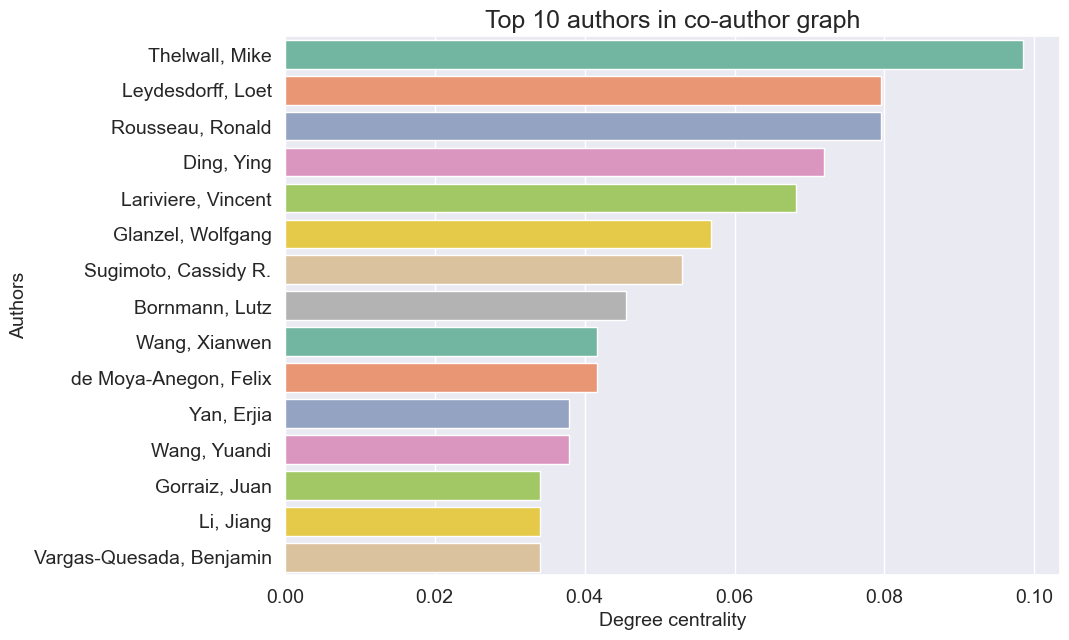

In [19]:
# Visualizing the top 15 co-authors by degree centrality score
sns.set(font_scale=.75)
cent_df_d15 = cent_df.sort_values('degree', ascending = False)[:15]
cent_df_d15.index.name = "author"
cent_df_d15.reset_index(inplace=True)
print()
plt.figure(figsize=(10,7))
ax = sns.barplot(y = "author", x = "degree", data = cent_df_d15, palette = "Set2");
ax.set_alpha(0.8)
ax.set_title("Top 10 authors in co-author graph", fontsize = 18)
ax.set_ylabel("Authors", fontsize=14);
ax.set_xlabel("Degree centrality", fontsize=14);
ax.tick_params(axis = 'both', which = 'major', labelsize = 14)

In [20]:
solo = []
co = []
for i in cent_df_d15["author"]:
    # Calculate solo authorship rate
    so = np.round((len(df[(df['AF'].str.contains(i)) & (df['num-Authors'] == 1)])) / (len(df[df['AF'].str.contains(i)])), decimals = 2)
    solo.append(so)
    # Calculate co-authorship rate
    co.append(1-so)
print(solo, co)



[0.11, 0.17, 0.13, 0.13, 0.02, 0.13, 0.03, 0.17, 0.0, 0.0, 0.15, 0.0, 0.0, 0.08, 0.0] [0.89, 0.83, 0.87, 0.87, 0.98, 0.87, 0.97, 0.83, 1.0, 1.0, 0.85, 1.0, 1.0, 0.92, 1.0]


In [21]:
# Create top 10 authors dataframe
authors = pd.DataFrame(zip(solo, co), columns = ["solo", "coauthor"])
authors["author"] = cent_df_d15["author"]
# Rearrange columns
authors = authors[["author", "solo", "coauthor"]]
authors

,author,solo,coauthor
0,"Thelwall, Mike",0.11,0.89
1,"Leydesdorff, Loet",0.17,0.83
2,"Rousseau, Ronald",0.13,0.87
3,"Ding, Ying",0.13,0.87
4,"Lariviere, Vincent",0.02,0.98
5,"Glanzel, Wolfgang",0.13,0.87
6,"Sugimoto, Cassidy R.",0.03,0.97
7,"Bornmann, Lutz",0.17,0.83
8,"Wang, Xianwen",0.00,1.00
9,"de Moya-Anegon, Felix",0.00,1.00


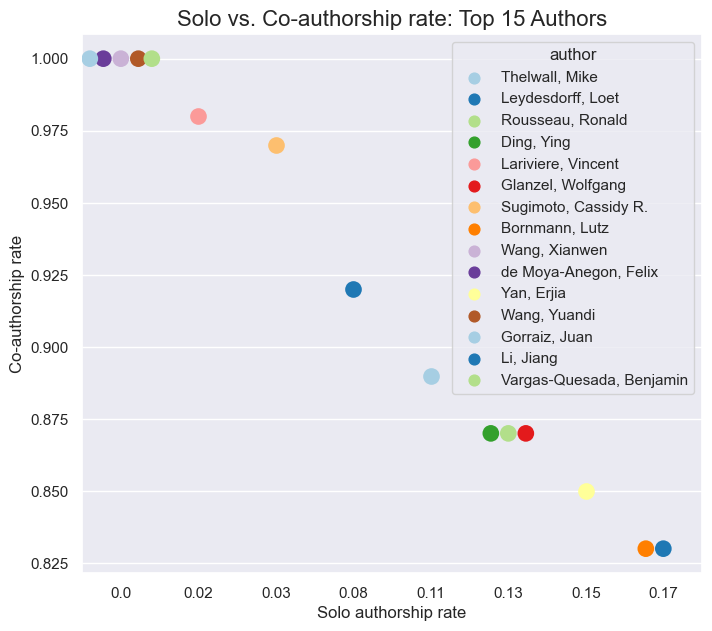

In [22]:
sns.set(rc={'figure.figsize':(8,7)})
fig = sns.swarmplot(x = "solo", y = "coauthor", hue = "author", data = authors, s = 12, palette = "Paired")
plt.title("Solo vs. Co-authorship rate: Top 15 Authors", fontsize = 16)
plt.xlabel("Solo authorship rate")
plt.ylabel("Co-authorship rate")
plt.show()

In [23]:
# Community detection
partition = community.best_partition(giant_coauthor) 
modularity = community.modularity(partition, giant_coauthor)
print("Modularity:", modularity)

Modularity: 0.8386923811009591


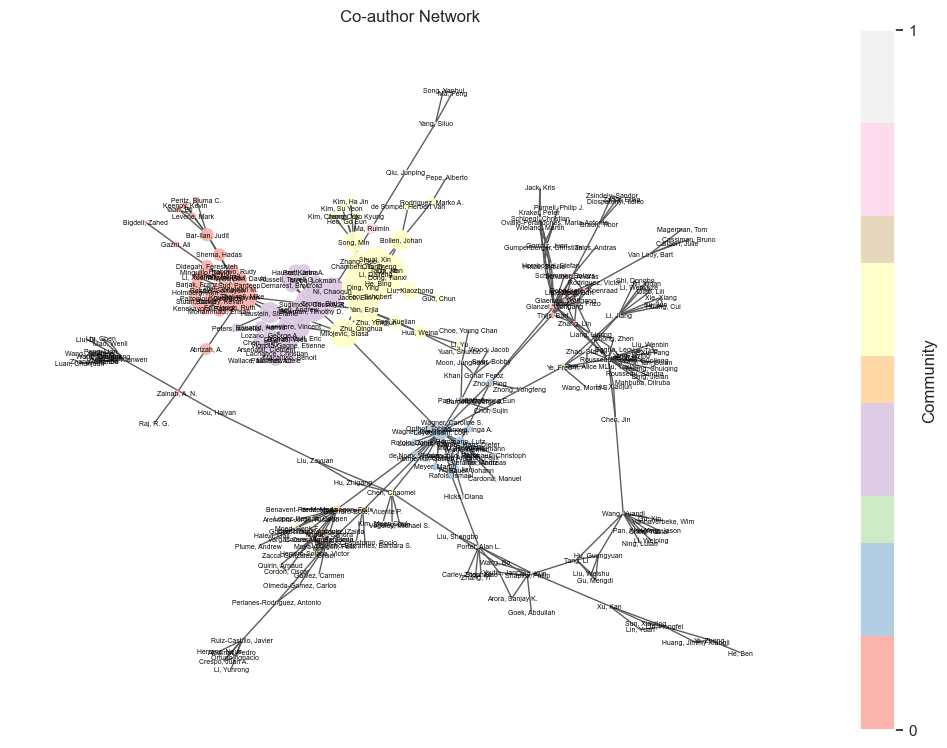

In [24]:
import matplotlib.pyplot as plt
import networkx as nx

# Assuming you've already computed eigenvector centrality and stored it in 'eig'
# and assuming giant_coauthor is your network

# Visualizing the co-author network
plt.figure(figsize=(10, 7))

# Node size based on eigenvector centrality
size = [2000 * eig[node] for node in giant_coauthor]

# Node color based on community membership or some other attribute
# Let's assume 'partition' is a dictionary with node-community mappings
colors = [partition[node] for node in giant_coauthor]

# Create a colormap to map community labels to colors
# Using a light colormap to ensure dark text is readable
cmap = plt.cm.get_cmap('Pastel1', max(partition.values()) + 1)

# Draw the network
nx.draw_spring(
    giant_coauthor, 
    node_size=size, 
    with_labels=True, 
    font_size=5, 
    font_color='black',  # Dark text for better readability
    node_color=colors,  # Node color now based on community membership
    cmap=cmap,  # Apply the light colormap
    edge_color="#555555",  # Changed edge color to a dark grey for better contrast
    alpha=0.95
)

# Display a colorbar to show community color mappings
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])
plt.colorbar(sm, label='Community', ticks=range(max(partition.values()) + 1))

# Display the visualization
plt.title('Co-author Network')
plt.show()



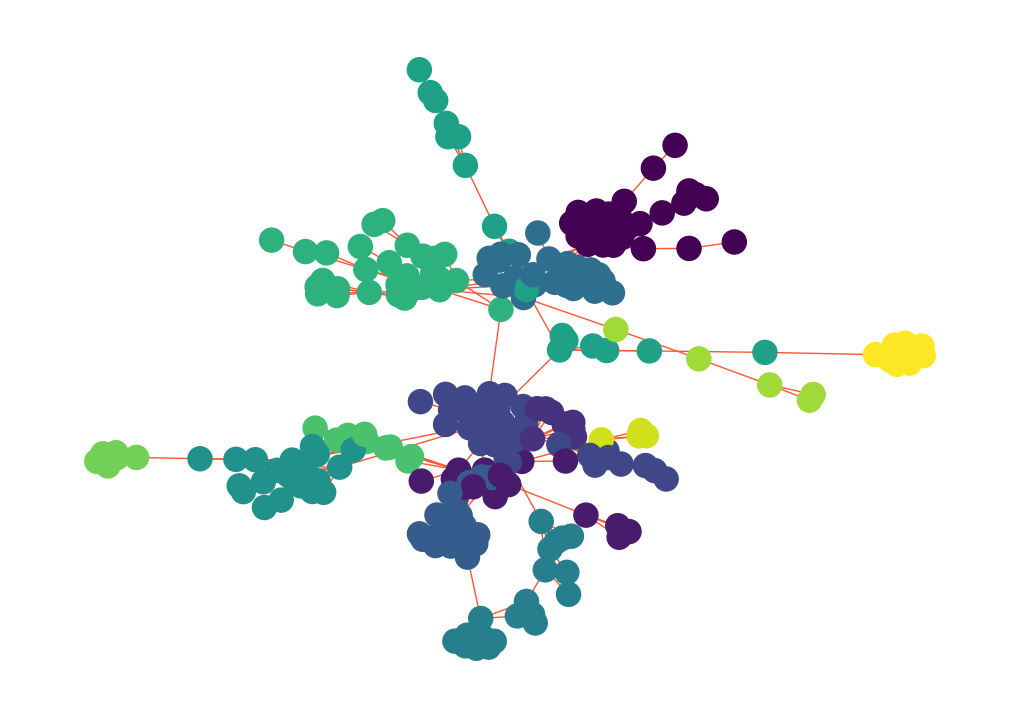

In [25]:
# Visualizing the communities
# Generates a different graph each time
plt.figure(figsize=(10, 7))
colors = [partition[n] for n in giant_coauthor.nodes()]
my_colors = plt.cm.viridis  # Corrected colormap to viridis
nx.draw(giant_coauthor, node_color=colors, cmap=my_colors, edge_color="#FF5733")  # Changed edge color to #FF5733



In [26]:
# Transform the record collection into a format for use with natural language processing applications
data = coll_rec.forNLP("topic_model_data.csv", lower=True, removeNumbers=True, removeNonWords=True, removeWhitespace=True)

# Convert the raw text into a list.
docs = data['abstract']
docs

['recent studies of authorship attribution have used machinelearning methods including regularized multinomial logistic regression neural nets support vector machines and the nearest shrunken centroid classifier to identify likely authors of disputed texts these methods are all limited by an inability to perform openset classification and account for text and corpus size we propose a customized bayesian logitnormalbetabinomial classification model for supervised authorship attribution the model is based on the betabinomial distribution with an explicit inverse relationship between extrabinomial variation and text size the model internally estimates the relationship of extrabinomial variation to text size and uses markov chain monte carlo mcmc to produce distributions of posterior authorship probabilities instead of point estimates we illustrate the method by training the machinelearning methods as well as the openset bayesian classifier on undisputed papers of the federalist and testin

In [27]:
# Defining a function to clean the text
def clean(docs):
    # Insert function for preprocessing the text
    def sent_to_words(sentences):
        for sentence in sentences:
            yield (simple_preprocess(str(sentence), deacc = True))
    # Tokenize the text
    tokens = sent_to_words(docs)
    # Create stopwords set
    stop = set(stopwords.words("english"))
    # Create lemmatizer
    lemmatiser = WordNetLemmatizer()
    # Remove stopwords from text
    tokens_stopped = [[word for word in post if word not in stop] for post in tokens]
    # Lemmatize text
    tokens_cleaned = [[lemmatiser.lemmatize(word) for word in post] for post in tokens_stopped]
    # Return cleaned text
    return tokens_cleaned

# Cleaning up the raw documents
cleaned_docs = clean(docs)
cleaned_docs

[['recent',
  'study',
  'authorship',
  'attribution',
  'used',
  'machinelearning',
  'method',
  'including',
  'regularized',
  'multinomial',
  'logistic',
  'regression',
  'neural',
  'net',
  'support',
  'vector',
  'machine',
  'nearest',
  'shrunken',
  'centroid',
  'classifier',
  'identify',
  'likely',
  'author',
  'disputed',
  'text',
  'method',
  'limited',
  'inability',
  'perform',
  'openset',
  'classification',
  'account',
  'text',
  'corpus',
  'size',
  'propose',
  'customized',
  'bayesian',
  'classification',
  'model',
  'supervised',
  'authorship',
  'attribution',
  'model',
  'based',
  'betabinomial',
  'distribution',
  'explicit',
  'inverse',
  'relationship',
  'extrabinomial',
  'variation',
  'text',
  'size',
  'model',
  'internally',
  'estimate',
  'relationship',
  'extrabinomial',
  'variation',
  'text',
  'size',
  'us',
  'markov',
  'chain',
  'monte',
  'carlo',
  'mcmc',
  'produce',
  'distribution',
  'posterior',
  'authorsh

In [28]:
# Creating a dictionary
id2word = corpora.Dictionary(cleaned_docs)
print(id2word)

Dictionary(21943 unique tokens: ['account', 'alexander', 'attributed', 'attribution', 'author']...)


In [29]:
# Filtering infrequent and over frequent words
id2word.filter_extremes(no_below=15, no_above=0.5)
# Creating a document-term matrix
corpus = [id2word.doc2bow(doc) for doc in cleaned_docs]

In [ ]:
# Building an LDA model with 10 topics
model = ldamodel.LdaModel(corpus = corpus,
                          num_topics = 10,
                          id2word = id2word,
                          passes = 10,
                          update_every = 1,
                          chunksize = 1000,
                          per_word_topics = True,
                          random_state = 1)
# Printing the topic-word distributions
pprint(model.print_topics())

In [ ]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(model, corpus, id2word, mds = "tsne")
vis